## Learning Objectives
At the end of this module, you should be able to:
- query whether a point is inside a polygon
- join two vector data sets based on their features’ locations

Practical questions:
- If you have two areas — a commercial and a residential zone, how might you identify where they overlap?
- Imagine you have datasets for schools and hospitals—how could you link them spatially to find the closest hospitals near each school?
- What types of data would you need to start analyzing spatial relationships between locations?
- Can you think of real-world applications where knowing the location relationships (inside, near, overlapping) is critical?

## Point-in-polygon queries

Finding out if a point is located inside or outside of an area, or finding out if a line intersects with another line or polygon are fundamental geospatial operations that are often used to select data based on location. Such spatial queries are one of the typical steps of the workflow when doing spatial analysis. Performing a
spatial join between two spatial datasets is one of the most typical applications where Point in Polygon (PIP) query is used.

For further reading about PIP and other geometric operations, see Chapter 4.2 in Smith, Goodchild & Longley: [Geospatial Analysis - 6th edition](https://www.spatialanalysisonline.com/HTML/index.html).

### How to check if point is inside a polygon?

Computationally, detecting if a point is inside a polygon is most commonly done using a specific formula called [Ray Casting algorithm](https://en.wikipedia.org/wiki/Point_in_polygon#Ray_casting_algorithm). Luckily, we do not need to create such a function ourselves for conducting the Point in Polygon (PIP) query. Instead, we can take advantage of [Shapely's binary predicates](https://shapely.readthedocs.io/en/stable/manual.html#binary-predicates) that can evaluate the topological relationships between geographical objects, such as the PIP query.

<br>

> ### Ray-Casting Algorithm
> The **ray-casting algorithm** is a common method used to determine whether a given point lies inside or outside of a polygon. This algorithm is widely used in spatial analysis and GIS.
>
> #### How It Works
> - **Cast a Ray**: A ray (straight line) is extended from the point in question to infinity in one direction.
> - **Count Intersections**: Count how many times this ray intersects with the edges of the polygon.
>   - If the ray crosses the edges an **odd number of times**, the point is considered to be **inside** the polygon.
>   - If the ray crosses the edges an **even number of times**, the point is **outside** the polygon.
>
> ![Example of ray casting of a polygon](img/ray-casting.png)
> 
> *Example of ray casting of a polygon.*
> <br>
> #### Why This Works
> This method leverages the idea that a ray entering and exiting the polygon will cross an edge each time it enters or exits. An odd count of intersections means the point is "trapped" inside; an even count means it is outside.

## Point-in-polygon queries on Shapely geometries

There are basically two ways of conducting PIP in Shapely:

1. using a function called
   [within()](https://shapely.readthedocs.io/en/stable/manual.html#object.within)
   that checks if a point is within a polygon
2. using a function called
   [contains()](https://shapely.readthedocs.io/en/stable/manual.html#object.contains)
   that checks if a polygon contains a point


> **Note**
>
> Even though we are discussing a **Point** in Polygon operation, it is also possible to check if a LineString or Polygon is inside another Polygon.



Let’s first create a couple of point geometries:

In [1]:
import shapely.geometry
point1 = shapely.geometry.Point(24.952242, 60.1696017)
point2 = shapely.geometry.Point(24.976567, 60.1612500)

... and a polygon:

In [2]:
polygon = shapely.geometry.Polygon(
    [
        (24.950899, 60.169158),
        (24.953492, 60.169158),
        (24.953510, 60.170104),
        (24.950958, 60.169990)
    ]
)

Let’s check if the points are `within()` the polygon:

In [3]:
point1.within(polygon)

True

In [4]:
point2.within(polygon)

False

It seems that the first point is inside the polygon, but the second one is not.

We can turn the logic of the look-up around. Rather than checking if the point is within the polygon, we can also ask whether the polygon `contains()` the point:

In [5]:
polygon.contains(point1)

True

In [6]:
polygon.contains(point2)

False

> **Hint:** The two ways of checking the spatial relationship are complementary and yield
> equivalent results; [contains()](https://shapely.readthedocs.io/en/stable/manual.html#object.contains)
> is inverse to [within()](https://shapely.readthedocs.io/en/stable/manual.html#object.within),
> and vice versa.
>
> Then, which one should you use? Well, it depends:
>
> - If you have **many points and just one polygon** and want to find out which points are inside the polygon, you might need to iterate over the points and check one at a time if it is **within()** the polygon.
> - If you have **many polygons and just one point** and want to find out which polygon contains the point, you might need to iterate over the polygons until you find one that **contains()** the point.


## Point-in-polygon queries on geopandas.GeoDataFrame

In the following example we find which of the university addresses are located within a given county in Michigan.

In [7]:
import geopandas as gpd

michigan = gpd.read_file("data/Michigan_counties.gpkg")
michigan.head()

,FIPSCODE,FIPSNUM,NAME,LABEL,TYPE,CNTY_CODE,SQKM,SQMILES,ACRES,VER,LAYOUT,PENINSULA,GlobalID,created_us,created_da,last_edite,last_edi_1,geometry
0,045,45,Eaton,Eaton County,County,045,1500.471019,579.335099,370774.463482,EC,landscape,lower,{2AD85D85-9779-4D2F-96B5-E8B8AF9FEB21},GISOWNER,2018-11-02,GISOWNER,2019-11-12,"POLYGON Z ((580473.125 247137.314 0.000, 58047..."
1,001,1,Alcona,Alcona County,County,001,1800.450219,695.157716,444900.938180,17A,landscape,lower,{314D437D-1A2F-4238-88BF-6AE79959F357},GISOWNER,2018-11-02,GISOWNER,2018-11-02,"POLYGON Z ((712946.906 443502.966 0.000, 71279..."
2,003,3,Alger,Alger County,County,003,2435.677649,940.420398,601869.054558,17A,landscape,upper,{7D879E7A-D907-4B20-A291-7C10CC6D8F5F},GISOWNER,2018-11-02,GISOWNER,2018-11-02,"MULTIPOLYGON Z (((509078.447 682113.339 0.000,..."
3,005,5,Allegan,Allegan County,County,005,2181.729030,842.370288,539116.984155,17A,landscape,lower,{C159E538-9DCA-4E9C-BBB1-0ECBC50681F0},GISOWNER,2018-11-02,GISOWNER,2018-11-02,"POLYGON Z ((517669.724 246394.309 0.000, 51853..."
4,007,7,Alpena,Alpena County,County,007,1541.515772,595.182567,380916.842808,17A,landscape,lower,{ABFFF3E9-3EBA-45EF-8117-BB6D22CB8BCF},GISOWNER,2018-11-02,GISOWNER,2018-11-02,"MULTIPOLYGON Z (((704999.216 520520.715 0.000,..."


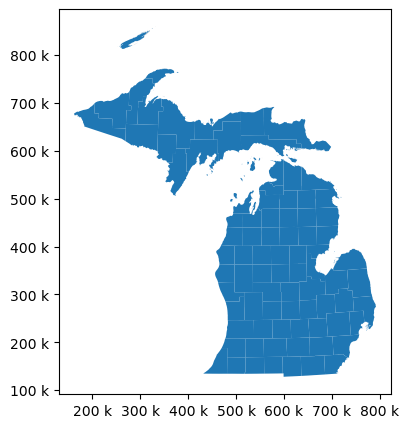

In [8]:
import matplotlib.ticker as ticker

ax = michigan.plot(figsize=(5, 5))

# Format to show numbers in thousands (km)
ax.xaxis.set_major_formatter(ticker.EngFormatter())
ax.yaxis.set_major_formatter(ticker.EngFormatter())

In [9]:
# print out the coordinate reference system (CRS) attribute
michigan.crs


<Projected CRS: EPSG:3078>
Name: NAD83 / Michigan Oblique Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - Michigan.
- bounds: (-90.42, 41.69, -82.13, 48.32)
Coordinate Operation:
- name: Michigan Oblique Mercator (meters)
- method: Hotine Oblique Mercator (variant A)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

Specifically, we want to find out which universities are within the Washtenaw County. Let’s start by plotting a multi-layer map that shows all counties, the Washtenaw County, and all universities in one map:

In [10]:
washtenaw = michigan[michigan.NAME == "Washtenaw"]
washtenaw

,FIPSCODE,FIPSNUM,NAME,LABEL,TYPE,CNTY_CODE,SQKM,SQMILES,ACRES,VER,LAYOUT,PENINSULA,GlobalID,created_us,created_da,last_edite,last_edi_1,geometry
80,161,161,Washtenaw,Washtenaw County,County,161,1870.94594,722.376266,462320.810221,17A,landscape,lower,{23CBD42A-604F-423F-ADCA-29A33C381228},GISOWNER,2018-11-02,GISOWNER,2018-11-02,"POLYGON Z ((703397.164 173614.566 0.000, 70286..."


In [11]:
colleges = gpd.read_file("data/Michigan_colleges.gpkg")

# make sure the coordinate reference systems (CRS) match
colleges = colleges.to_crs(michigan.crs)

colleges.head()

,address,id,addr,geometry
0,"North Ingalls, 500, South State Street, Old Fo...",1,"500 S State St, Ann Arbor, MI 48109",POINT (686349.974 195111.186)
1,"Trowbridge Road, River Trail Neighborhood, Eas...",2,"220 Trowbridge Rd, East Lansing, MI 48824",POINT (624306.564 242275.973)
2,"Welcome Center, 42, West Warren Avenue, Midtow...",3,"42 W Warren Ave, Detroit, MI 48202",POINT (741548.457 204996.011)
3,"Einstein Bros. Bagels, 1, North Campus Drive, ...",4,"1 Campus Dr, Allendale, MI 49401",POINT (509194.947 268334.841)
4,"Metro/Bronco - W. MIchigan Ave, 1903, West Mic...",5,"1903 W Michigan Ave, Kalamazoo, MI 49008",POINT (532068.830 192791.902)


> **Hint: Plotting multiple map layers**
>
> To plot several map layers in one figure, use the `ax` parameter to specify in which *axes* data should be plotted.
>
> The easiest way to obtain an *axes* is to save the return value of the first `plot()` (see below). Another option is to create [subplots()](https://geo-python-site.readthedocs.io/en/latest/notebooks/L7/advanced-plotting.html#using-subplots), possibly with only one row and one column.


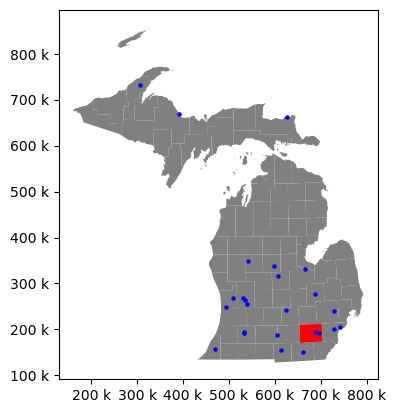

In [12]:
ax = michigan.plot(facecolor="grey")
washtenaw.plot(ax=ax, facecolor="red")
colleges.plot(ax=ax, color="blue", markersize=5)

# Format to show numbers in thousands (km)
ax.xaxis.set_major_formatter(ticker.EngFormatter())
ax.yaxis.set_major_formatter(ticker.EngFormatter())

As seen above, some points are within the Washtenaw County, but others are not. To find out which are the ones inside the county, we can use a **point-in-polygon query** on the entire `geopandas.GeoDataFrame`. Its method `within()` returns Boolean (`True`/`False`) values that indicate whether or not a row’s geometry is contained in the supplied *other* geometry:

<div style="border: 1px solid #ffa726; background-color: #ffe0b2; padding: 15px; border-radius: 5px;">

**Geometry vs. geometry column**

In the example below, we use `washtenaw.geometry.iloc[0]` to obtain a single value, a `shapely.geometry.Polygon`, instead of an entire column (a `GeoSeries`). This ensures that each row’s geometry in the `addresses` data frame is matched against *the same polygon*. In contrast, if we ran `within()` against a column, the operation would be carried out row-wise: the first address point would be checked against the first polygon, the second address point against the second polygon, and so forth.

Check the [documentation for `within()`](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoSeries.within.html) to learn more!

</div>




In [13]:
colleges.within(washtenaw.geometry.iloc[0])

0      True
1     False
2     False
3     False
4     False
5     False
6      True
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
dtype: bool

This list of Boolean values, also called a *mask array* can be used to filter
the input data frame:

In [14]:
colleges_in_washtenaw = colleges[ colleges.within(washtenaw.geometry.iloc[0]) ]
colleges_in_washtenaw

,address,id,addr,geometry
0,"North Ingalls, 500, South State Street, Old Fo...",1,"500 S State St, Ann Arbor, MI 48109",POINT (686349.974 195111.186)
6,"900, Oakwood Street, College Heights, Ypsilant...",7,"900 Oakwood St, Ypsilanti, MI 48197",POINT (695464.528 191461.774)


Finally, let’s plot this list of addresses one more time to visually verify that all of them, indeed, are located within the Washtenaw County:

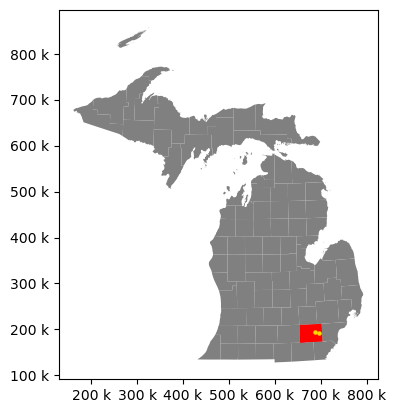

In [15]:
ax = michigan.plot(facecolor="grey")
washtenaw.plot(ax=ax, facecolor="red")

colleges_in_washtenaw.plot(
    ax=ax,
    color="gold",
    markersize=5
)

# Format to show numbers in thousands (km)
ax.xaxis.set_major_formatter(ticker.EngFormatter())
ax.yaxis.set_major_formatter(ticker.EngFormatter())

Perfect! Now we are left with only the (golden) points which, indeed, are
inside the red polygon. That’s exactly what we wanted!

## Intersect
 
Similar to the spatial relationships `within` and `contains`, another common geospatial query asks whether two geometries intersect or touch.

Both queries are implemented in `shapely`:
- [intersects()](https://shapely.readthedocs.io/en/stable/manual.html#object.intersects): two objects intersect if the boundary or interior of one object intersect in any way with the boundary or interior of the other object.
- [touches()](https://shapely.readthedocs.io/en/stable/manual.html#object.touches): two objects touch if the objects have at least one point in common, but their interiors do not intersect with any part of the other object.

Let’s try these functions out using two lines:

In [16]:
import shapely.geometry
line1 = shapely.geometry.LineString([(0, 0), (1, 1)])
line2 = shapely.geometry.LineString([(1, 1), (0, 2)])

In [17]:
line1.intersects(line2)

True

The lines intersect. Do they also touch?

In [18]:
line1.touches(line2)

True

`line1` touches `line2`. Adding them both to a multi-line is a quick way of
drawing them inside a Jupyter notebook:

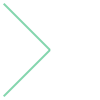

In [19]:
shapely.geometry.MultiLineString([line1, line2])

We can see that they share point (1, 1), in which line1 ends, and line2 begins. The two lines do not intersect otherwise (‘in their interior’), so the predicate `touch()` is true.

If the lines share some of their interior, that would not be counted as touching. For instance, line1 does not touch line1 (itself), but fulfils all requirements to be counted as `intersect()`ing with itself:

In [20]:
line1.touches(line1)

False

In [21]:
line1.intersects(line1)

True

## Spatial join

*Spatial joins* are operations that combine data from two or more spatial data sets based on their geometric relationship. In previous sections, we learnt two specific cases of spatial joins: Point-in-polygon queries and intersects-queries. However, there is more to using the geometric relationship between features and between entire layers.

Spatial join operations require two input parameters: the *predicate*, i.e., the geometric condition that needs to be met between two geometries, and the *join-type*: whether only rows with matching geometries are kept, or all of one input table’s rows, or all records. 

*Geopandas* (using `shapely` to implement geometric relationships) [supports a standard set of geometric predicates](https://geopandas.org/en/stable/docs/user_guide/mergingdata.html#binary-predicate-joins), that is similar to most GIS analysis tools and applications:

- intersects
- contains
- within
- touches
- crosses
- overlaps

Geometric predicates are expressed as verbs, so they have an intuitive meaning. See the [shapely user manual](https://shapely.readthedocs.io/en/stable/manual.html#binary-predicates) for a detailed description of each geometric predicate.

<div style="border: 1px solid #d4edda; background-color: #e6f4ea; padding: 15px; border-radius: 5px;">

**Tip**

The [PyGIS book](https://pygis.io/docs/e_spatial_joins.html) provides a great overview of spatial predicates and join-types, complete with explanatory drawings.

</div>


<img src="img/spatial-relations.png" width="600">

- The top row shows spatial predicates in which the geometries A and B are clearly disjoint from each other, contained or within each other, or identical to each other.
- When the geometries have at least one point in common, the geometries are said to be intersecting with each other. Thus, in this figure, all the comparisons except the first one (disjoint) are True, i.e. the geometries intersect with each other. 
- The bottom row shows examples of spatial relationships that are slightly “special cases” in one way or another. When two geometries touch each other, they have at least one point in common (at the border in this case), but their interiors do not intersect with each other. 
- When the interiors of the geometries A and B are partially on top of each other and partially outside of each other, the geometries are overlapping with each other. 
- The spatial predicate for covers is when the interior of geometry B is almost totally within A, but they share at least one common coordinate at the border. 
- Similarly, if geometry A is almost totally contained by the geometry B (except at least one common coordinate at the border) the spatial predicate is called covered by.

In terms of the *join-type*, geopandas implements four different options:

- *left*: keep all records of the *left* data frame, fill with empty values if no match, keep *left* geometry column
- *right*: keep all records of the *right* data frame, fill with empty values if no match, keep *right* geometry column
- *inner*: keep only records of matching records, keep *left* geometry column
- *outer*: all records from both datasets are kept, regardless if the records meet the specified spatial relationship criteria for a join. Rows that do not have a match are filled with empty values.

![Spatial join types](img/join_types.jpg)

## Load input data

As an example, let’s find the population density at each of the addresses by combining with data from the MiEJScreen SocioEconomic Category data.

The socioeconomic data is available from [GIS Open Data for the State of Michigan](https://gis-michigan.opendata.arcgis.com/datasets/egle::miejscreen-socioeconomic-category/about)

In [22]:
import geopandas as gpd

colleges = gpd.read_file("data/Michigan_colleges.gpkg")
social = gpd.read_file('data/Michigan_SocioEconomics.zip')

# print out the columns in the socioeconomic data
social.columns

Index(['OBJECTID_1', 'GEOID', 'ALAND', 'AWATER', 'NAME', 'State', 'County',
       'B01001_001', 'Shape_Leng', 'GEOID_1', 'TRACT', 'TpopEducat',
       'Education', 'EducationP', 'Educatio_1', 'PopGTE5Lin', 'TPopGTE5',
       'LingIsolP', 'LingIsolPL', 'TPOP', 'POVRateLT2', 'POVRateL_1',
       'POVRateL_2', 'PopCivilLa', 'Unemployed', 'Unemploy_1', 'Unemploy_2',
       'TPopH', 'HousingE', 'HousingEP', 'HousingEP1', 'HousingE_1', 'TPop2',
       'WhiteAlone', 'WhiteAlo_1', 'Minorities', 'Minoriti_1', 'Minoriti_2',
       'Minoriti_3', 'Tpop_1', 'MalesLT5', 'FemalesLT5', 'TotalLT5',
       'TotalLT5P', 'TotalLT5PL', 'PopGTE65', 'PopGTE65P', 'PopGTE65PL',
       'SOCECONAve', 'SOCECONA_1', 'B01001_002', 'ALANDSQMi', 'PopDenMiSq',
       'B23025_cal', 'B19049_001', 'B03002_003', 'B03002_004', 'B03002_005',
       'B03002_006', 'B03002_007', 'B03002_008', 'B03002_009', 'B03002_012',
       'B03002_cal', 'B03002_c_1', 'B03002_c_2', 'B03002_c_3', 'B03002_c_4',
       'B03002_c_5', 'B03002_c

In [23]:
social.head()

,OBJECTID_1,GEOID,ALAND,AWATER,NAME,State,County,B01001_001,Shape_Leng,GEOID_1,...,B03002_c_2,B03002_c_3,B03002_c_4,B03002_c_5,B03002_c_6,B03002_c_7,Shape__Len,Shape__Are,GlobalID,geometry
0,1,26001970600,73252248.0,6711048.0,Census Tract 9706,Michigan,Alcona County,1447,48591.586514,2.600197e+10,...,0.3,0.0,0.0,0.0,2.4,0.4,0.0,0.0,0c70a9a8-99a5-40e9-8e8e-1d4be0191bfb,"POLYGON ((712930.284 452334.545, 712930.284 45..."
1,2,26005030200,29604849.0,120799.0,Census Tract 302,Michigan,Allegan County,3161,31021.628934,2.600503e+10,...,0.4,3.6,0.0,0.0,0.3,3.1,0.0,0.0,fb5eed1a-2ba1-4f28-8759-b0b0844158a0,"POLYGON ((488689.886 244808.134, 488689.886 24..."
2,3,26005030300,184705676.0,1062630.0,Census Tract 303,Michigan,Allegan County,7723,78329.952690,2.600503e+10,...,0.0,0.4,0.0,0.1,2.0,2.0,0.0,0.0,0893114b-a8a7-4d22-91dd-bda67aeeb4a0,"POLYGON ((517669.613 246395.222, 517669.613 24..."
3,4,26005030401,93622240.0,65204.0,Census Tract 304.01,Michigan,Allegan County,7722,52742.324687,2.600503e+10,...,0.2,0.2,0.0,0.0,2.3,2.6,0.0,0.0,79c7515e-08c2-4f6b-8344-29e774b0ed2c,"POLYGON ((527422.934 246419.649, 527422.934 24..."
4,5,26005030402,88113267.0,1874959.0,Census Tract 304.02,Michigan,Allegan County,5258,54733.373571,2.600503e+10,...,0.0,3.1,0.0,0.0,1.1,3.1,0.0,0.0,c06ae31f-cfe8-4fe6-a3e1-b1aa7fdc6218,"POLYGON ((537055.682 246472.893, 537055.682 24..."


The socioeconomic data have many columns. Let’s extract the population density **PopDenMiSq** and geometry columns.

In [24]:
population_density = social[["PopDenMiSq", "geometry"]]
population_density.head()

,PopDenMiSq,geometry
0,51.161742,"POLYGON ((712930.284 452334.545, 712930.284 45..."
1,276.540916,"POLYGON ((488689.886 244808.134, 488689.886 24..."
2,108.293788,"POLYGON ((517669.613 246395.222, 517669.613 24..."
3,213.623252,"POLYGON ((527422.934 246419.649, 527422.934 24..."
4,154.552854,"POLYGON ((537055.682 246472.893, 537055.682 24..."


## Join input layers

Now we are ready to perform the spatial join between the two layers. Remember: the aim is to find the population density around each of the address points. We want to attach population density information from the `population_density` polygon layer to the `addresses` point layer, depending on whether the **point is within the polygon**. During this operation, we want to **retain the geometries of the point layer**.

Before we go ahead with the join operation, we have to make sure the two layers are in the same cartographic reference system:

In [25]:
if colleges.crs != population_density.crs:
    print("CRS are not identical")

CRS are not identical


They do not share the same CRS, let’s reproject one of them:

In [26]:
population_density = population_density.to_crs(colleges.crs)

Now we are ready to carry out the actual spatial join using the
[`geopandas.GeoDataFrame.sjoin()`](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.sjoin.html)
method. Remember, we want to use a *within* geometric predicate and retain the
point layer’s geometries (in the example below the *left* data frame).

In [27]:
colleges_with_population = colleges.sjoin(
    population_density,
    how="left",
    predicate="within"
)
colleges_with_population.head()

,address,id,addr,geometry,index_right,PopDenMiSq
0,"North Ingalls, 500, South State Street, Old Fo...",1,"500 S State St, Ann Arbor, MI 48109",POINT (-83.73838 42.28346),1845,18709.810544
1,"Trowbridge Road, River Trail Neighborhood, Eas...",2,"220 Trowbridge Rd, East Lansing, MI 48824",POINT (-84.48023 42.72085),491,115.461065
2,"Welcome Center, 42, West Warren Avenue, Midtow...",3,"42 W Warren Ave, Detroit, MI 48202",POINT (-83.06515 42.35700),2048,9345.553462
3,"Einstein Bros. Bagels, 1, North Campus Drive, ...",4,"1 Campus Dr, Allendale, MI 49401",POINT (-85.88562 42.96594),1641,4123.048871
4,"Metro/Bronco - W. MIchigan Ave, 1903, West Mic...",5,"1903 W Michigan Ave, Kalamazoo, MI 49008",POINT (-85.60983 42.28500),584,4812.650454


That looks great! We now have an address data set with population density information attached to it. 

As a final task, let’s look at how to plot data using a *graduated* cartographic visualisation scheme. 

The `geopandas.GeoDataFrame.plot()` method can vary the map colours depending on a column’s values by passing its name as a named argument `column`. On top of that, the method accepts many arguments to influence the style of the map. Among them are **scheme** and **cmap** that define the [categorisation scheme](https://geopandas.org/en/stable/gallery/choropleths.html), and the [colour map](https://matplotlib.org/stable/tutorials/colors/colormaps.html). 

Many more arguments are passed through to **matplotlib**, such as **markersize** to set the size of point symbols, and **facecolor** to set the colour of polygon areas. To draw a legend, set **legend** to **True**, to set the size of the figure, pass a tuple (with values in inch) as **figsize**.

Text(0.5, 1.0, 'Population density around colleges')

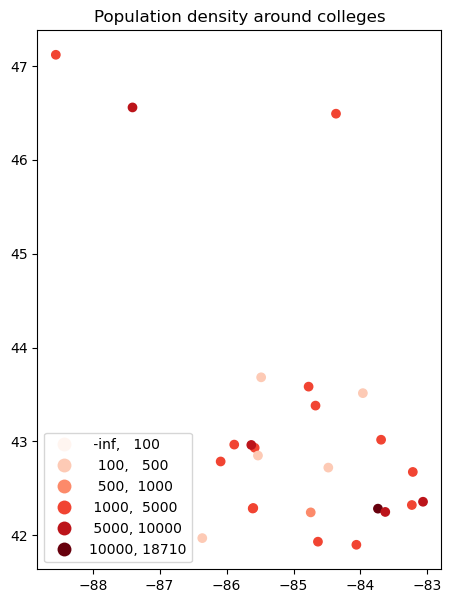

In [28]:
ax = colleges_with_population.plot(
    figsize=(7, 7),
    column="PopDenMiSq",
    cmap="Reds",
    scheme="UserDefined",
    classification_kwds={'bins': [100, 500, 1000, 5000, 10000]},
    legend=True,
    legend_kwds={'fmt': "{:.0f}"}
)
ax.set_title("Population density around colleges")

We can apply the same arguments to plot a population density map using the entire `population_density` data set:

Text(0.5, 1.0, 'Population density in the state of Michigan')

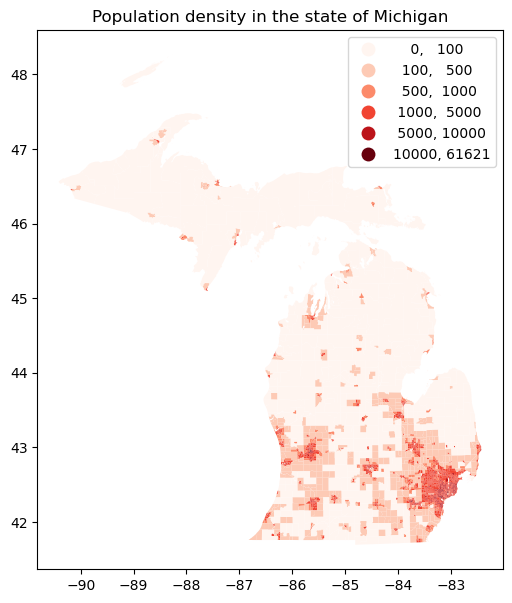

In [29]:
ax = population_density.plot(
    figsize=(7, 7),
    column="PopDenMiSq",
    cmap="Reds",
    scheme="UserDefined",
    classification_kwds={'bins': [100, 500, 1000, 5000, 10000]},
    legend=True,
    legend_kwds={'fmt': "{:.0f}"}
)
ax.set_title("Population density in the state of Michigan")


Finally, remember to save the output data frame to a file. We can append it to the existing *GeoPackage* by specifying a new layer name:

In [30]:
colleges_with_population.to_file(
    "data/Michigan_colleges_with_pop.gpkg",
    layer="colleges_with_population"
)